# EDA and Preprocessing
This notebook explores the raw ECG and PCG signals to determine the necessary preprocessing steps before training our models.

In [14]:
import os
import sys
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
from scipy.signal import butter, filtfilt, freqz
from IPython.display import Audio, display

# Importing preprocessing functions from src
sys.path.append(os.path.abspath('..'))
from src.preprocessing import preprocess_signals, segment_signals

# Importing data

# Set paths
DATA_DIR = '../data/raw/HFrEF_5_folds'

# Concatenate all 5 fold label files
label_files = [os.path.join(DATA_DIR, f'fold_{i}_label.csv') for i in range(5)]
df = pd.concat((pd.read_csv(f, header=None, names=['Subject_ID', 'LVEF']) for f in label_files), ignore_index=True)

# Calculate HFrEF Labels
# - less than or equal to 40% LVEF is considered HFrEF
df['Label'] = (df['LVEF'] <= 0.4).astype(int)

print(df.head()) # preview

        Subject_ID  LVEF  Label
0  1005263204_APEX  0.72      0
1  1005263204_LLSB  0.72      0
2  1005263204_LUSB  0.72      0
3  1005263204_RUSB  0.72      0
4  1007048209_APEX  0.62      0


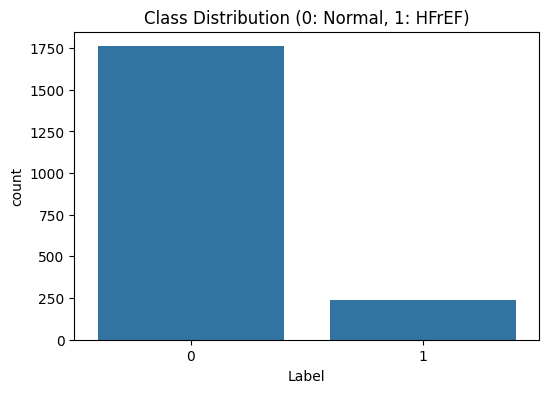

Total Subjects: 2000
Normal Subjects (Label 0): 1760
HFrEF Subjects (Label 1): 240


In [7]:
# Check the exact imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label')
plt.title('Class Distribution (0: Normal, 1: HFrEF)')
plt.show()

print(f"Total Subjects: {len(df)}")
print(f"Normal Subjects (Label 0): {len(df[df['Label'] == 0])}")
print(f"HFrEF Subjects (Label 1): {df['Label'].sum()}")

In [8]:
# find the ECG and PCG paths by searching through the fold directories
def get_signal_paths(record_id, base_dir=DATA_DIR):
    # record_id already looks like '1005263204_APEX'
    for i in range(5):
        fold_dir = os.path.join(base_dir, f'fold_{i}')
        ecg_path = os.path.join(fold_dir, f"{record_id}_ECG.wav")
        pcg_path = os.path.join(fold_dir, f"{record_id}_PCG.wav")
        
        if os.path.exists(ecg_path) and os.path.exists(pcg_path):
            return ecg_path, pcg_path
            
    raise FileNotFoundError(f"Files for record {record_id} not found.")

# get the first record from the dataframe to test
sample_record = df['Subject_ID'].iloc[0]
ecg_file, pcg_file = get_signal_paths(sample_record)

# load the signals at their correct sampling rates
ecg_sig, ecg_sr = librosa.load(ecg_file, sr=500)
pcg_sig, pcg_sr = librosa.load(pcg_file, sr=4000)

## Preprocessing Steps

### 1. Signal Filtering and Normalization
Raw physiological signals contain noise that confuses neural networks. 
* **Bandpass Filtering:** We use a Butterworth filter to isolate the frequencies that matter. For the ECG, we keep 0.5 to 40 Hz to remove baseline wander (usually caused by breathing). For the PCG, we keep 25 to 400 Hz to isolate the actual heart sounds.
* **Z-score Normalization:** We subtract the mean and divide by the standard deviation. This forces both the ECG and PCG to be on the exact same numerical scale (a mean of 0 and a standard deviation of 1), which is a hard requirement before fusing them into a single deep learning model.

### 2. Signal Segmentation (Skipped For Now)
Our raw recordings are 30 seconds long. We chop them into synchronized 5-second chunks based on their specific sampling rates.
* **ECG (500 Hz):** 5 seconds * 500 samples/second = 2,500 samples per segment.
* **PCG (4000 Hz):** 5 seconds * 4000 samples/second = 20,000 samples per segment.

This step does two things: it multiplies our total dataset size by 6, and it keeps the input arrays small enough to train efficiently on a standard Kaggle GPU without running out of memory.

In [9]:
ecg_clean, pcg_clean = preprocess_signals(ecg_sig, pcg_sig)
# ecg_segments, pcg_segments = segment_signals(ecg_clean, pcg_clean, segment_length_sec=5)

# print(f"Original length: 30 seconds")
# print(f"Created {len(ecg_segments)} synchronized segments of 5 seconds each.")

### 3. Extracting and Saving to Disk (PyTorch Tensors)
Instead of processing `.wav` files on the fly during training, the entire dataframe is iterated through once, process the signals into 5-second segments, and save them directly as PyTorch `.pt` tensors.

Saving them as `.pt` files saves a conversion step in the PyTorch `Dataset` class, speeding up data loading during training. Also, a new metadata CSV is generated to map each segmented file to its label.

In [10]:
PROCESSED_DIR = '../data/processed/full/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

processed_records = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing records"):
    record_id = row['Subject_ID']
    label = row['Label']
    
    try:
        ecg_path, pcg_path = get_signal_paths(record_id)
        
        # load raw signals
        ecg_sig, _ = librosa.load(ecg_path, sr=500)
        pcg_sig, _ = librosa.load(pcg_path, sr=4000)
        
        # preprocess and don't segment
        ecg_clean, pcg_clean = preprocess_signals(ecg_sig, pcg_sig)
        # ecg_segs, pcg_segs = segment_signals(ecg_clean, pcg_clean, segment_length_sec=5)
        
        # save each signal as a PyTorch tensor
        ecg_filename = f"{record_id}_ecg.pt"
        pcg_filename = f"{record_id}_pcg.pt"
        
        # convert to float32 tensors and save
        torch.save(torch.tensor(ecg_clean, dtype=torch.float32), os.path.join(PROCESSED_DIR, ecg_filename))
        torch.save(torch.tensor(pcg_clean, dtype=torch.float32), os.path.join(PROCESSED_DIR, pcg_filename))
        
        processed_records.append({
            'Record_ID': record_id,
            # 'Segment_Index': 0,
            'ECG_File': ecg_filename,
            'PCG_File': pcg_filename,
            'Label': label
        })
    except Exception as e:
        print(f"Error processing {record_id}: {e}")

# save the new metadata mapping
processed_df = pd.DataFrame(processed_records)
processed_df.to_csv(os.path.join(PROCESSED_DIR, 'processed_metadata_clean.csv'), index=False)
# print(f"Finished processing. Saved {len(processed_df)} total segments.")
print(f"Finished processing. Saved {len(processed_df)} total signals.")

Processing records: 100%|██████████| 2000/2000 [00:33<00:00, 60.54it/s]

Finished processing. Saved 2000 total signals.


## Displaying the Signals
The following code displays the raw and preprocessed signals for a selected record.

Record ID : 1009948644_APEX
LVEF      : 0.570
Label     : 0 (Normal)


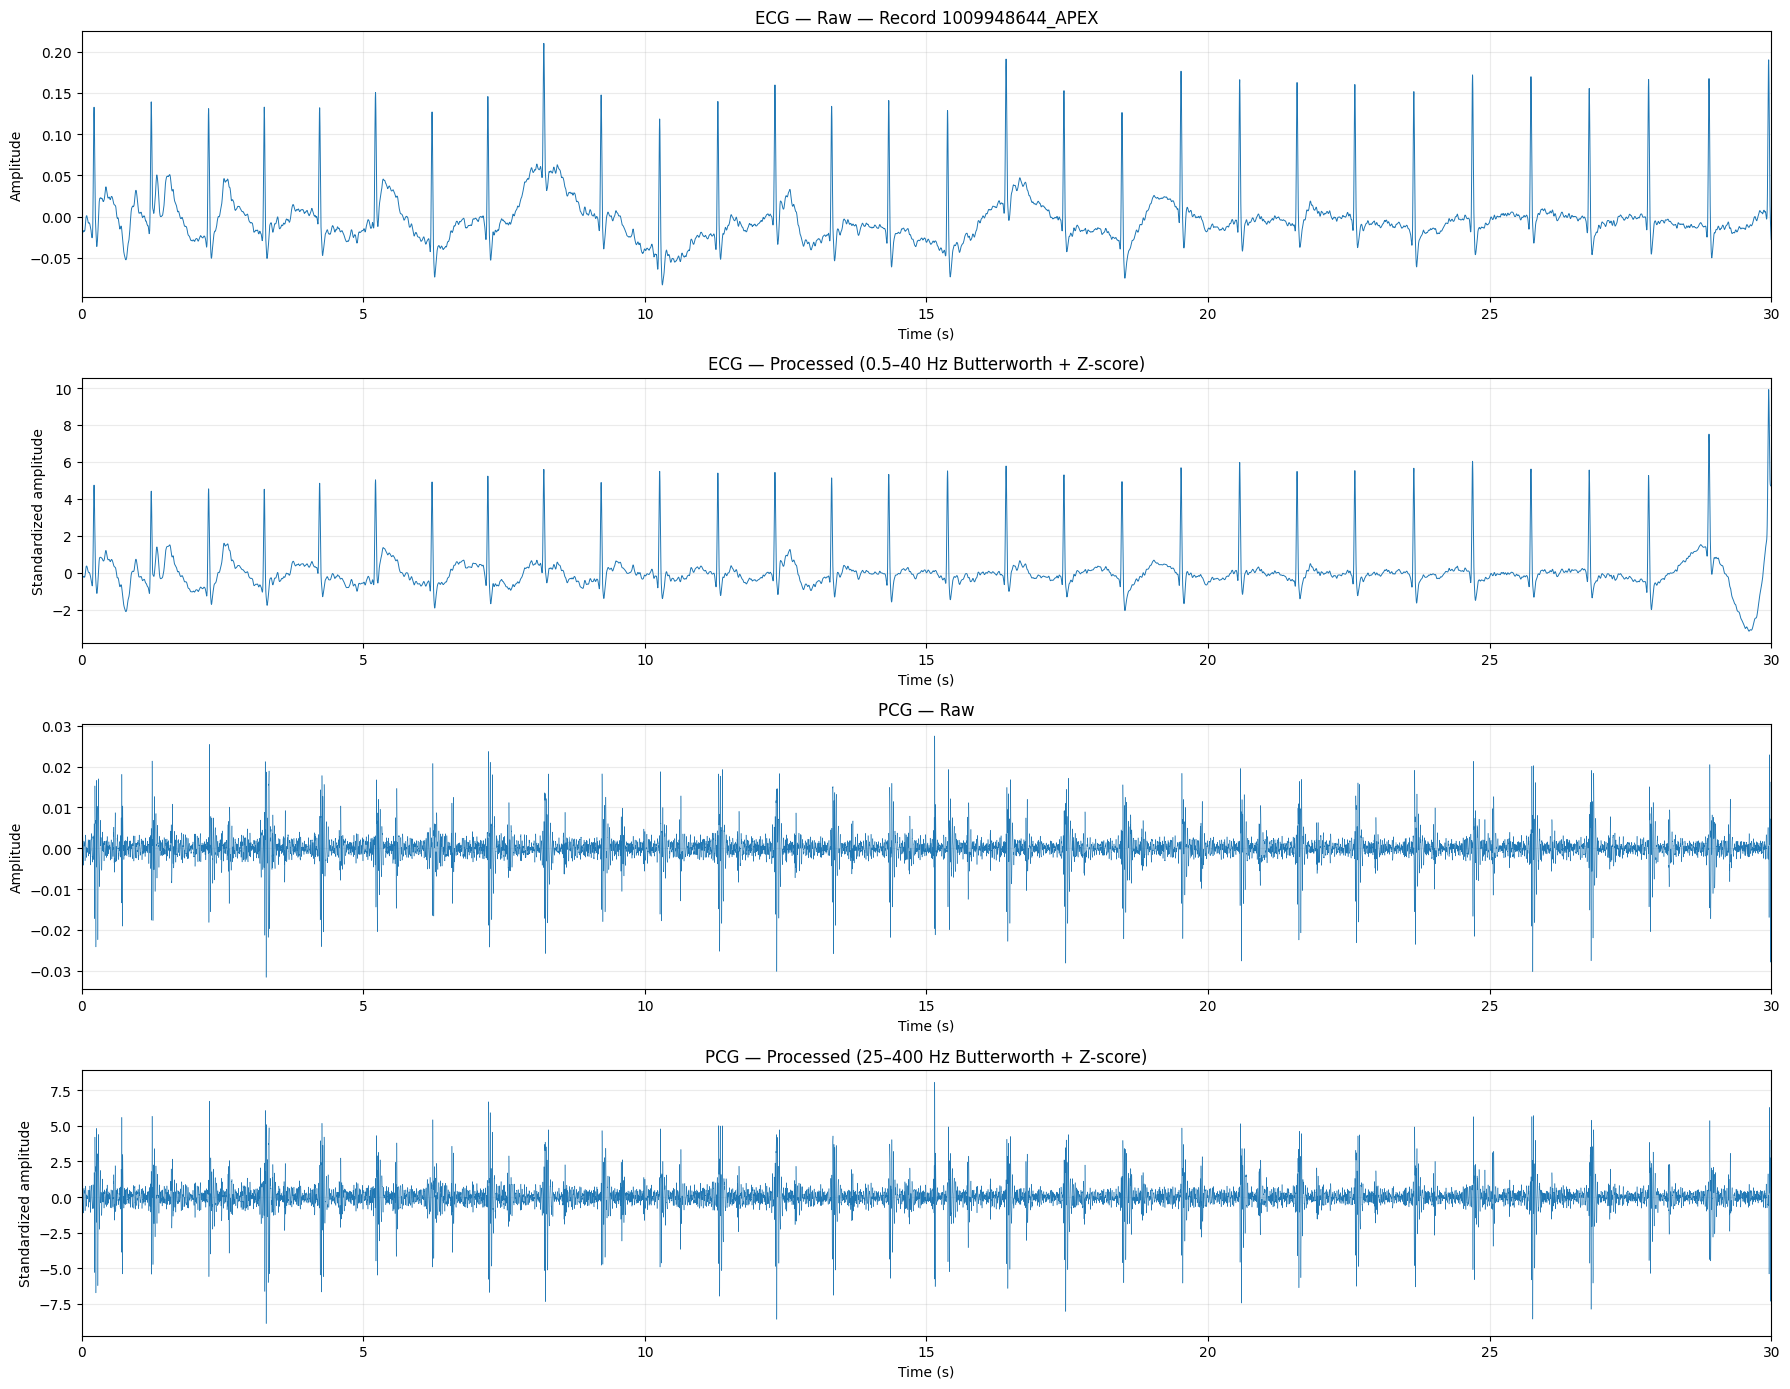

PCG RAW — 30 seconds


PCG PROCESSED — 30 seconds


In [19]:
RECORD_NUMBER = 20  # <----- select the record number

RECORD_ID = str(df.loc[RECORD_NUMBER, "Subject_ID"])
LABEL = int(df.loc[RECORD_NUMBER, "Label"])
LVEF = float(df.loc[RECORD_NUMBER, "LVEF"])

ecg_file, pcg_file = get_signal_paths(RECORD_ID)

# load using the sampling rates defined by the project
ecg_raw, ecg_sr = librosa.load(ecg_file, sr=500, mono=True)

pcg_raw, pcg_sr = librosa.load(pcg_file, sr=4000, mono=True)

ECG_FS = 500
PCG_FS = 4000
DISPLAY_SECONDS = 30

print(f"Record ID : {RECORD_ID}")
print(f"LVEF      : {LVEF:.3f}")
print(f"Label     : {LABEL} ({'HFrEF' if LABEL == 1 else 'Normal'})")

ecg_processed, pcg_processed = preprocess_signals(ecg_raw, pcg_raw)

# Extract exactly 30 seconds for display/audio
ECG_SAMPLES_30 = ECG_FS * DISPLAY_SECONDS
PCG_SAMPLES_30 = PCG_FS * DISPLAY_SECONDS

ecg_raw_30 = ecg_raw[:ECG_SAMPLES_30]
ecg_processed_30 = ecg_processed[:ECG_SAMPLES_30]

pcg_raw_30 = pcg_raw[:PCG_SAMPLES_30]
pcg_processed_30 = pcg_processed[:PCG_SAMPLES_30]

# Time axes
t_ecg = np.arange(len(ecg_raw_30)) / ECG_FS
t_pcg = np.arange(len(pcg_raw_30)) / PCG_FS

fig, axes = plt.subplots(4, 1, figsize=(18, 14))

# ECG RAW 
axes[0].plot(t_ecg, ecg_raw_30, linewidth=0.7)
axes[0].set_title(f"ECG — Raw — Record {RECORD_ID}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, DISPLAY_SECONDS)
axes[0].grid(True, alpha=0.25)

# ECG PROCESSED 
axes[1].plot(t_ecg, ecg_processed_30, linewidth=0.7)
axes[1].set_title("ECG — Processed (0.5–40 Hz Butterworth + Z-score)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Standardized amplitude")
axes[1].set_xlim(0, DISPLAY_SECONDS)
axes[1].grid(True, alpha=0.25)

# PCG RAW
axes[2].plot(t_pcg, pcg_raw_30, linewidth=0.35)
axes[2].set_title("PCG — Raw")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlim(0, DISPLAY_SECONDS)
axes[2].grid(True, alpha=0.25)

# PCG PROCESSED 
axes[3].plot(t_pcg, pcg_processed_30, linewidth=0.35)
axes[3].set_title("PCG — Processed (25–400 Hz Butterworth + Z-score)")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Standardized amplitude")
axes[3].set_xlim(0, DISPLAY_SECONDS)
axes[3].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f"PCG RAW — {DISPLAY_SECONDS} seconds")
display(
    Audio(
        data=pcg_raw_30,
        rate=PCG_FS,
        normalize=True
    )
)

print(f"PCG PROCESSED — {DISPLAY_SECONDS} seconds")
display(
    Audio(
        data=pcg_processed_30,
        rate=PCG_FS,
        normalize=True
    )
)